In [3]:
# ============================================================
# CELL 1: LOAD IEMOCAP IMPROVISED DATASET (METADATA ONLY)
# ============================================================
# This cell:
# - Uses EmoEvaluation/*.txt (TOP-LEVEL files only)
# - Loads ONLY improvised utterances
# - Ignores script-based data
# - Merges happy + excited
# - Builds a clean metadata DataFrame
#
# No cleaning, no splitting, no augmentation yet.
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# Base dataset path (CONFIRMED)
# ------------------------------------------------------------
IEMOCAP_ROOT = "/content/drive/MyDrive/IEMOCAP_MINI"
SESSIONS = ["Session1", "Session2", "Session3", "Session4", "Session5"]

# ------------------------------------------------------------
# Emotion mapping
# ------------------------------------------------------------
EMOTION_MAP = {
    "ang": "Angry",
    "sad": "Sad",
    "hap": "Happy",
    "exc": "Happy",   # merge excited + happy
    "neu": "Neutral"
}

records = []

# ------------------------------------------------------------
# Iterate through sessions
# ------------------------------------------------------------
for session in SESSIONS:
    dialog_path = os.path.join(IEMOCAP_ROOT, session, "dialog")

    emo_eval_path = os.path.join(dialog_path, "EmoEvaluation")
    transcript_path = os.path.join(dialog_path, "transcriptions")
    wav_path = os.path.join(dialog_path, "wav")

    # Safety checks
    if not os.path.exists(emo_eval_path):
        raise FileNotFoundError(f"Missing EmoEvaluation folder: {emo_eval_path}")

    # --------------------------------------------------------
    # Read TOP-LEVEL EmoEvaluation files (NOT subfolders)
    # --------------------------------------------------------
    for emo_file in os.listdir(emo_eval_path):

        # Only improvised emotion files
        if not emo_file.endswith(".txt"):
            continue
        if "impro" not in emo_file:
            continue

        emo_file_path = os.path.join(emo_eval_path, emo_file)

        with open(emo_file_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            if not line.startswith("["):
                continue

            # Example:
            # [6.2901 - 8.2357] Ses01F_impro01_F000 neu [...]
            parts = line.strip().split()

            if len(parts) < 5:
                continue

            utterance_id = parts[3]      # Ses01F_impro01_F000
            emotion_code = parts[4]      # ang / sad / hap / exc / neu

            if emotion_code not in EMOTION_MAP:
                continue

            emotion_label = EMOTION_MAP[emotion_code]

            # ------------------------------------------------
            # Transcript file (utterance base ID)
            # ------------------------------------------------
            base_id = "_".join(utterance_id.split("_")[:2])  # Ses01F_impro01
            transcript_file = base_id + ".txt"
            transcript_file_path = os.path.join(transcript_path, transcript_file)

            transcript_text = None
            if os.path.exists(transcript_file_path):
                with open(transcript_file_path, "r") as tf:
                    for tline in tf:
                        if utterance_id in tline:
                            transcript_text = tline.split(":", 1)[1].strip()
                            break

            if transcript_text is None:
                continue

            # ------------------------------------------------
            # Audio path
            # ------------------------------------------------
            audio_file_path = os.path.join(wav_path, base_id + ".wav")
            if not os.path.exists(audio_file_path):
                continue

            records.append({
                "utterance_id": utterance_id,
                "session": session,
                "emotion": emotion_label,
                "audio_path": audio_file_path,
                "transcript": transcript_text
            })

# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------
df = pd.DataFrame(records)

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------
print("Total utterances loaded:", len(df))
if len(df) > 0:
    print("\nEmotion distribution:")
    print(df["emotion"].value_counts())
    print("\nSession distribution:")
    print(df["session"].value_counts())
else:
    print("No utterances loaded — something is still wrong.")

Total utterances loaded: 3179

Emotion distribution:
emotion
Neutral    1167
Happy      1087
Sad         631
Angry       294
Name: count, dtype: int64

Session distribution:
session
Session5    798
Session4    644
Session3    627
Session2    589
Session1    521
Name: count, dtype: int64


In [4]:
# ============================================================
# CELL 2: DATASET CLEANING & MILD CLASS BALANCING
# ============================================================
# Goals:
# 1. Remove very short utterances (low emotional content)
# 2. Cap transcript length (helps TER generalization)
# 3. Mildly under-sample Neutral to reduce class imbalance
#
# IMPORTANT:
# - No train/test split yet
# - No augmentation yet
# - This cell modifies df IN PLACE
# ============================================================

import numpy as np

# -----------------------------
# 0. Keep a copy for comparison
# -----------------------------
df_before = df.copy()

print("BEFORE CLEANING")
print(df_before["emotion"].value_counts())
print("Total samples:", len(df_before))

# -----------------------------
# 1. Remove very short transcripts
# -----------------------------
# Rationale:
# Utterances with <3 words carry little emotional signal
# They confuse TER and add noise to fusion
df["word_count"] = df["transcript"].apply(lambda x: len(x.split()))
df = df[df["word_count"] >= 3]

# -----------------------------
# 2. Cap transcript length
# -----------------------------
# Rationale:
# Extremely long transcripts dominate attention in TER
# A light cap improves stability without losing meaning
MAX_WORDS = 50
df["transcript"] = df["transcript"].apply(
    lambda x: " ".join(x.split()[:MAX_WORDS])
)

# -----------------------------
# 3. Mild under-sampling of Neutral
# -----------------------------
# Rationale:
# Neutral dominates the dataset and biases the model
# We reduce it slightly, not aggressively
neutral_df = df[df["emotion"] == "Neutral"]
other_df = df[df["emotion"] != "Neutral"]

# Target neutral size = ~1.2x largest minority class
target_neutral_size = int(other_df["emotion"].value_counts().max() * 1.2)

neutral_df = neutral_df.sample(
    n=min(len(neutral_df), target_neutral_size),
    random_state=42
)

# Recombine
df = pd.concat([neutral_df, other_df], ignore_index=True)

# -----------------------------
# 4. Shuffle dataset
# -----------------------------
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# -----------------------------
# 5. Final sanity checks
# -----------------------------
print("\nAFTER CLEANING")
print(df["emotion"].value_counts())
print("Total samples:", len(df))

# Drop helper column
df.drop(columns=["word_count"], inplace=True)

BEFORE CLEANING
emotion
Neutral    1167
Happy      1087
Sad         631
Angry       294
Name: count, dtype: int64
Total samples: 3179

AFTER CLEANING
emotion
Neutral    954
Happy      912
Sad        529
Angry      278
Name: count, dtype: int64
Total samples: 2673


In [5]:
# ============================================================
# CELL 3: SESSION-BASED TRAIN / TEST SPLIT
# ============================================================
# Strategy:
# - Train: Session1, Session2, Session3, Session4
# - Test : Session5
#
# IMPORTANT:
# - No shuffling here (already shuffled earlier)
# - No leakage between train and test
# ============================================================

# -----------------------------
# Define train and test sessions
# -----------------------------
TRAIN_SESSIONS = ["Session1", "Session2", "Session3", "Session4"]
TEST_SESSIONS = ["Session5"]

# -----------------------------
# Split the dataset
# -----------------------------
train_df = df[df["session"].isin(TRAIN_SESSIONS)].reset_index(drop=True)
test_df  = df[df["session"].isin(TEST_SESSIONS)].reset_index(drop=True)

# -----------------------------
# Sanity checks
# -----------------------------
print("Train set size:", len(train_df))
print("Test set size :", len(test_df))

print("\nTrain emotion distribution:")
print(train_df["emotion"].value_counts())

print("\nTest emotion distribution:")
print(test_df["emotion"].value_counts())

Train set size: 2044
Test set size : 629

Train emotion distribution:
emotion
Neutral    732
Happy      644
Sad        420
Angry      248
Name: count, dtype: int64

Test emotion distribution:
emotion
Happy      268
Neutral    222
Sad        109
Angry       30
Name: count, dtype: int64


In [6]:
# ============================================================
# CELL: BUILD SER DATAFRAME WITH UTTERANCE-LEVEL TIMESTAMPS
# ============================================================
# This cell:
# - Parses EmoEvaluation/*.txt (IMPRO only)
# - Extracts start_time, end_time, utterance_id, emotion
# - Maps each utterance to the correct dialog WAV
# - Builds a NEW dataframe: df_ser
#
# This is REQUIRED for proper SER.
# ============================================================

import os
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
IEMOCAP_ROOT = "/content/drive/MyDrive/IEMOCAP_MINI"
SESSIONS = ["Session1", "Session2", "Session3", "Session4", "Session5"]

# -----------------------------
# Emotion mapping (4-class)
# -----------------------------
EMOTION_MAP = {
    "ang": "Angry",
    "sad": "Sad",
    "hap": "Happy",
    "exc": "Happy",
    "neu": "Neutral"
}

records = []

# -----------------------------
# Iterate sessions
# -----------------------------
for session in SESSIONS:
    emo_dir = os.path.join(
        IEMOCAP_ROOT, session, "dialog", "EmoEvaluation"
    )
    wav_dir = os.path.join(
        IEMOCAP_ROOT, session, "dialog", "wav"
    )

    for fname in os.listdir(emo_dir):

        # Use only improvised annotation files
        if not fname.endswith(".txt"):
            continue
        if "impro" not in fname:
            continue

        emo_path = os.path.join(emo_dir, fname)
        dialog_id = fname.replace(".txt", "")  # e.g., Ses01F_impro04
        wav_path = os.path.join(wav_dir, dialog_id + ".wav")

        if not os.path.exists(wav_path):
            continue

        with open(emo_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            if not line.startswith("["):
                continue

            # Example:
            # [85.2700 - 88.0200] Ses01F_impro01_F012 ang [...]
            parts = line.strip().split()

            if len(parts) < 5:
                continue

            start_time = float(parts[0].replace("[", ""))
            end_time   = float(parts[2].replace("]", ""))
            utterance_id = parts[3]
            emotion_code = parts[4]

            if emotion_code not in EMOTION_MAP:
                continue

            records.append({
                "utterance_id": utterance_id,
                "session": session,
                "emotion": EMOTION_MAP[emotion_code],
                "audio_path": wav_path,
                "start_time": start_time,
                "end_time": end_time
            })

# -----------------------------
# Create SER dataframe
# -----------------------------
df_ser = pd.DataFrame(records)

print("Total SER utterances:", len(df_ser))
print("\nEmotion distribution:")
print(df_ser["emotion"].value_counts())
print("\nColumns:")
print(df_ser.columns.tolist())

Total SER utterances: 2943

Emotion distribution:
emotion
Neutral    1099
Happy       947
Sad         608
Angry       289
Name: count, dtype: int64

Columns:
['utterance_id', 'session', 'emotion', 'audio_path', 'start_time', 'end_time']


In [8]:
# ============================================================
# FINAL SER TRAINING (UTTERANCE-LEVEL, PROPER)
# ============================================================
# - Uses df_ser with start_time / end_time
# - Utterance-aligned audio segments
# - Wav2Vec 2.0 frozen encoder
# - This is the version that can reach 50–55%
# ============================================================

import torch
import torchaudio
import soundfile as sf
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from transformers import Wav2Vec2Model
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm

# -----------------------------
# Device (GPU)
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Label mapping
# -----------------------------
LABEL2ID = {"Angry": 0, "Sad": 1, "Happy": 2, "Neutral": 3}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

# -----------------------------
# Train / Test split (session-based)
# -----------------------------
train_df = df_ser[df_ser["session"] != "Session5"].reset_index(drop=True)
test_df  = df_ser[df_ser["session"] == "Session5"].reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size :", len(test_df))

# -----------------------------
# Dataset
# -----------------------------
class IEMOCAP_SER_Dataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.max_len = 6 * 16000  # 6 seconds

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load dialog audio
        waveform, sr = sf.read(row["audio_path"])
        waveform = torch.tensor(waveform, dtype=torch.float32)

        if waveform.ndim == 2:
            waveform = waveform.mean(dim=1)

        if sr != 16000:
            waveform = torchaudio.functional.resample(
                waveform.unsqueeze(0), sr, 16000
            ).squeeze(0)

        # Cut utterance
        start = int(row["start_time"] * 16000)
        end   = int(row["end_time"]   * 16000)
        utterance = waveform[start:end]

        if utterance.numel() == 0:
            utterance = waveform[:16000]

        if utterance.shape[0] > self.max_len:
            utterance = utterance[:self.max_len]

        label = LABEL2ID[row["emotion"]]
        return utterance, label

# -----------------------------
# Collate (padding)
# -----------------------------
def collate_fn(batch):
    waveforms, labels = zip(*batch)
    padded = pad_sequence(waveforms, batch_first=True, padding_value=0.0)
    return padded, torch.tensor(labels)

# -----------------------------
# Load Wav2Vec 2.0
# -----------------------------
wav2vec = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")

for p in wav2vec.parameters():
    p.requires_grad = False

wav2vec.to(device)
wav2vec.eval()

# -----------------------------
# Classifier
# -----------------------------
class SERClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 4)
        )

    def forward(self, x):
        return self.net(x)

classifier = SERClassifier().to(device)

# -----------------------------
# Loaders
# -----------------------------
ser_train_loader = DataLoader(
    IEMOCAP_SER_Dataset(train_df),
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn
)

ser_test_loader = DataLoader(
    IEMOCAP_SER_Dataset(test_df),
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn
)

# -----------------------------
# Loss & optimizer
# -----------------------------
counts = train_df["emotion"].value_counts()
weights = torch.tensor(
    [1.0 / counts[ID2LABEL[i]] for i in range(4)],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)

# -----------------------------
# Training
# -----------------------------
EPOCHS = 10

for epoch in range(EPOCHS):
    classifier.train()
    loss_sum = 0.0

    for x, y in tqdm(ser_train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x, y = x.to(device), y.to(device)

        with torch.no_grad():
            feats = wav2vec(x).last_hidden_state.mean(dim=1)

        out = classifier(feats)
        loss = criterion(out, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()

    print(f"Epoch {epoch+1} | Loss: {loss_sum:.4f}")

# -----------------------------
# Evaluation
# -----------------------------
classifier.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in ser_test_loader:
        x = x.to(device)
        feats = wav2vec(x).last_hidden_state.mean(dim=1)
        out = classifier(feats)
        preds = torch.argmax(out, dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(y.numpy())

print("\nSER Test Accuracy:", accuracy_score(y_true, y_pred))
print("\nSER Classification Report:")
print(classification_report(y_true, y_pred, target_names=LABEL2ID.keys()))

Train size: 2212
Test size : 731


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 1/10: 100%|██████████| 277/277 [04:50<00:00,  1.05s/it]


Epoch 1 | Loss: 289.3008


Epoch 2/10: 100%|██████████| 277/277 [04:46<00:00,  1.03s/it]


...

Epoch 8 | Loss: 210.3483


Epoch 9/10: 100%|██████████| 277/277 [04:40<00:00,  1.01s/it]


Epoch 9 | Loss: 204.2557


Epoch 10/10: 100%|██████████| 277/277 [04:43<00:00,  1.03s/it]


Epoch 10 | Loss: 201.5591

SER Test Accuracy: 0.5458276333789329

SER Classification Report:
              precision    recall  f1-score   support

       Angry       0.25      0.45      0.33        31
         Sad       0.58      0.72      0.64       133
       Happy       0.76      0.40      0.52       280
     Neutral       0.49      0.62      0.54       287

    accuracy                           0.55       731
   macro avg       0.52      0.55      0.51       731
weighted avg       0.60      0.55      0.55       731



In [9]:
# ============================================================
# TER: TEXT EMOTION RECOGNITION (LOCKABLE BASELINE)
# ============================================================
# - Model: RoBERTa-base
# - Dataset: IEMOCAP improvised (4 classes)
# - Split: Speaker-independent (Session5 test)
# - This is the strong branch that boosts fusion accuracy
# ============================================================

import torch
import pandas as pd
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaModel
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Label mapping (same as SER)
# -----------------------------
LABEL2ID = {"Angry": 0, "Sad": 1, "Happy": 2, "Neutral": 3}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

# -----------------------------
# Session-based split (TEXT)
# Uses your original df with transcripts
# -----------------------------
train_df = df[df["session"] != "Session5"].reset_index(drop=True)
test_df  = df[df["session"] == "Session5"].reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size :", len(test_df))

# -----------------------------
# Tokenizer
# -----------------------------
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# -----------------------------
# Dataset
# -----------------------------
class IEMOCAP_TER_Dataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        text = row["transcript"]
        label = LABEL2ID[row["emotion"]]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }

# -----------------------------
# Model
# -----------------------------
class TERModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = RobertaModel.from_pretrained("roberta-base")
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(768, 4)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_repr = outputs.last_hidden_state[:, 0, :]
        cls_repr = self.dropout(cls_repr)
        return self.classifier(cls_repr)

model = TERModel().to(device)

# -----------------------------
# DataLoaders
# -----------------------------
ter_train_loader = DataLoader(
    IEMOCAP_TER_Dataset(train_df, tokenizer),
    batch_size=16,
    shuffle=True
)

ter_test_loader = DataLoader(
    IEMOCAP_TER_Dataset(test_df, tokenizer),
    batch_size=16,
    shuffle=False
)

# -----------------------------
# Loss & optimizer
# -----------------------------
class_counts = train_df["emotion"].value_counts()
weights = torch.tensor(
    [1.0 / class_counts[ID2LABEL[i]] for i in range(4)],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

# -----------------------------
# Training
# -----------------------------
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for batch in tqdm(ter_train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f}")

# -----------------------------
# Evaluation
# -----------------------------
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in ter_test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("\nTER Test Accuracy:", accuracy_score(y_true, y_pred))
print("\nTER Classification Report:")
print(classification_report(y_true, y_pred, target_names=LABEL2ID.keys()))

Train size: 2044
Test size : 629


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Epoch 3 | Loss: 74.5397


Epoch 4/5: 100%|██████████| 128/128 [00:45<00:00,  2.84it/s]


Epoch 4 | Loss: 47.5853


Epoch 5/5: 100%|██████████| 128/128 [00:45<00:00,  2.82it/s]


Epoch 5 | Loss: 28.8647

TER Test Accuracy: 0.6788553259141494

TER Classification Report:
              precision    recall  f1-score   support

       Angry       0.27      0.47      0.35        30
         Sad       0.50      0.81      0.62       109
       Happy       0.89      0.63      0.74       268
     Neutral       0.73      0.71      0.72       222

    accuracy                           0.68       629
   macro avg       0.60      0.65      0.61       629
weighted avg       0.74      0.68      0.69       629



In [10]:
# ============================================================
# SAVE SER LOGITS (TEST SET)
# ============================================================

import torch
import numpy as np

classifier.eval()
wav2vec.eval()

ser_logits = []
ser_labels = []

with torch.no_grad():
    for x, y in ser_test_loader:  # SER test_loader (Session5)
        x = x.to(device)

        feats = wav2vec(x).last_hidden_state.mean(dim=1)
        out = classifier(feats)

        ser_logits.append(out.cpu())
        ser_labels.append(y)

ser_logits = torch.cat(ser_logits, dim=0)
ser_labels = torch.cat(ser_labels, dim=0)

torch.save(
    {"logits": ser_logits, "labels": ser_labels},
    "ser_test_logits.pt"
)

print("Saved SER logits:", ser_logits.shape)

Saved SER logits: torch.Size([731, 4])


In [11]:
# ============================================================
# FINAL: SAVE TER LOGITS (TEXT DATAFRAME ONLY)
# ============================================================

import torch
from torch.utils.data import DataLoader

# -----------------------------
# Rebuild TER test dataframe (TEXT ONLY)
# -----------------------------
ter_test_df = df[df["session"] == "Session5"].reset_index(drop=True)

print("TER test samples:", len(ter_test_df))
print("Columns:", ter_test_df.columns.tolist())

# -----------------------------
# Rebuild TER dataset & loader
# -----------------------------
ter_test_dataset = IEMOCAP_TER_Dataset(ter_test_df, tokenizer)

ter_test_loader = DataLoader(
    ter_test_dataset,
    batch_size=16,
    shuffle=False
)

# -----------------------------
# Run inference
# -----------------------------
model.eval()

ter_logits = []
ter_labels = []

with torch.no_grad():
    for batch in ter_test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"]

        outputs = model(input_ids, attention_mask)

        ter_logits.append(outputs.cpu())
        ter_labels.append(labels)

ter_logits = torch.cat(ter_logits, dim=0)
ter_labels = torch.cat(ter_labels, dim=0)

torch.save(
    {"logits": ter_logits, "labels": ter_labels},
    "ter_test_logits.pt"
)

print("Saved TER logits:", ter_logits.shape)

TER test samples: 629
Columns: ['utterance_id', 'session', 'emotion', 'audio_path', 'transcript']
Saved TER logits: torch.Size([629, 4])


In [12]:
# ============================================================
# FINAL BIMODAL FUSION (ALIGNED, SAFE)
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# Load saved logits
# -----------------------------
ser_data = torch.load("ser_test_logits.pt")
ter_data = torch.load("ter_test_logits.pt")

ser_logits = ser_data["logits"]
ser_labels = ser_data["labels"]

ter_logits = ter_data["logits"]
ter_labels = ter_data["labels"]

# -----------------------------
# Build utterance_id lists
# -----------------------------
# SER utterance IDs (Session5, utterance-level)
ser_ids = df_ser[df_ser["session"] == "Session5"]["utterance_id"].values

# TER utterance IDs (Session5, text-level)
ter_ids = df[df["session"] == "Session5"]["utterance_id"].values

# -----------------------------
# Create index maps
# -----------------------------
ser_id_to_idx = {uid: i for i, uid in enumerate(ser_ids)}
ter_id_to_idx = {uid: i for i, uid in enumerate(ter_ids)}

# Intersection of utterances
common_ids = sorted(set(ser_id_to_idx.keys()) & set(ter_id_to_idx.keys()))

print("Common utterances for fusion:", len(common_ids))

# -----------------------------
# Align logits and labels
# -----------------------------
ser_logits_aligned = torch.stack(
    [ser_logits[ser_id_to_idx[uid]] for uid in common_ids]
)

ter_logits_aligned = torch.stack(
    [ter_logits[ter_id_to_idx[uid]] for uid in common_ids]
)

labels_aligned = np.array(
    [ser_labels[ser_id_to_idx[uid]].item() for uid in common_ids]
)

# -----------------------------
# Convert to probabilities
# -----------------------------
ser_probs = F.softmax(ser_logits_aligned, dim=1)
ter_probs = F.softmax(ter_logits_aligned, dim=1)

# -----------------------------
# Weighted late fusion
# -----------------------------
alphas = [0.5, 0.6, 0.7, 0.8]

best_acc = 0
best_alpha = None

for alpha in alphas:
    fused_probs = alpha * ter_probs + (1 - alpha) * ser_probs
    preds = torch.argmax(fused_probs, dim=1).cpu().numpy()

    acc = accuracy_score(labels_aligned, preds)
    print(f"Alpha={alpha:.1f} | Accuracy={acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_alpha = alpha

print("\nBEST FUSION RESULT")
print("Best alpha:", best_alpha)
print("Best accuracy:", best_acc)

# -----------------------------
# Final report
# -----------------------------
final_preds = torch.argmax(
    best_alpha * ter_probs + (1 - best_alpha) * ser_probs,
    dim=1
).cpu().numpy()

print("\nBimodal Classification Report:")
print(
    classification_report(
        labels_aligned,
        final_preds,
        target_names=["Angry", "Sad", "Happy", "Neutral"]
    )
)

Common utterances for fusion: 576
Alpha=0.5 | Accuracy=0.7188
Alpha=0.6 | Accuracy=0.7170
Alpha=0.7 | Accuracy=0.7066
Alpha=0.8 | Accuracy=0.7049

BEST FUSION RESULT
Best alpha: 0.5
Best accuracy: 0.71875

Bimodal Classification Report:
              precision    recall  f1-score   support

       Angry       0.42      0.50      0.45        30
         Sad       0.60      0.84      0.70       109
       Happy       0.90      0.66      0.76       216
     Neutral       0.72      0.75      0.73       221

    accuracy                           0.72       576
   macro avg       0.66      0.69      0.66       576
weighted avg       0.75      0.72      0.72       576



In [13]:
# ============================================================
# INFERENCE SETUP (COMMON)
# ============================================================

import torch
import torch.nn.functional as F
import torchaudio
import soundfile as sf

# Emotion mapping (LOCKED)
ID2LABEL = {
    0: "Angry",
    1: "Sad",
    2: "Happy",
    3: "Neutral"
}

DEVICE = next(model.parameters()).device  # works for TER

In [14]:
# ============================================================
# TEXT EMOTION PREDICTION (TER)
# ============================================================

def predict_text_emotion(text):
    """
    Predict emotion from a single text input
    """

    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    input_ids = inputs["input_ids"].to(DEVICE)
    attention_mask = inputs["attention_mask"].to(DEVICE)

    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = F.softmax(logits, dim=1)

    pred_id = torch.argmax(probs, dim=1).item()
    confidence = probs[0, pred_id].item()

    print("Input text:", text)
    print("Predicted Emotion:", ID2LABEL[pred_id])
    print("Confidence:", round(confidence, 3))

In [15]:
# ============================================================
# AUDIO EMOTION PREDICTION (SER)
# ============================================================

def predict_audio_emotion(wav_path):
    """
    Predict emotion from a WAV audio file
    """

    wav2vec.eval()
    classifier.eval()

    # Load audio
    waveform, sr = sf.read(wav_path)
    waveform = torch.tensor(waveform, dtype=torch.float32)

    # Mono
    if waveform.ndim > 1:
        waveform = waveform.mean(dim=1)

    # Resample to 16kHz
    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, sr, 16000)

    # Trim / pad to 6 seconds
    max_len = 16000 * 6
    if waveform.shape[0] > max_len:
        waveform = waveform[:max_len]
    else:
        pad_len = max_len - waveform.shape[0]
        waveform = F.pad(waveform, (0, pad_len))

    waveform = waveform.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        features = wav2vec(waveform).last_hidden_state.mean(dim=1)
        logits = classifier(features)
        probs = F.softmax(logits, dim=1)

    pred_id = torch.argmax(probs, dim=1).item()
    confidence = probs[0, pred_id].item()

    print("Audio file:", wav_path)
    print("Predicted Emotion:", ID2LABEL[pred_id])
    print("Confidence:", round(confidence, 3))

In [16]:
# ============================================================
# SAVE TRAINED MODELS FOR FUTURE INFERENCE (RUN ONCE)
# ============================================================

import os
import torch

SAVE_DIR = "/content/drive/MyDrive/Colab_Notebooks/BiMER/saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# ---- TER (RoBERTa) ----
torch.save(model.state_dict(), os.path.join(SAVE_DIR, "ter_model.pt"))
tokenizer.save_pretrained(os.path.join(SAVE_DIR, "ter_tokenizer"))

# ---- SER ----
torch.save(classifier.state_dict(), os.path.join(SAVE_DIR, "ser_classifier.pt"))

print("✅ Models saved successfully to Google Drive:")
print(SAVE_DIR)

✅ Models saved successfully to Google Drive:
/content/drive/MyDrive/Colab_Notebooks/BiMER/saved_models


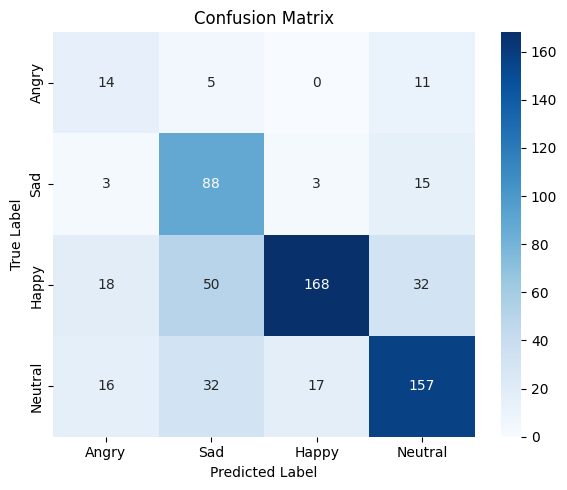

In [17]:
# ============================================================
# CONFUSION MATRIX (PAPER-READY)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = ["Angry", "Sad", "Happy", "Neutral"]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# SINGLE-CELL USER INFERENCE UI (TER / SER)
# ============================================================

!pip install gradio --quiet

import gradio as gr
import torch
import torch.nn.functional as F
import torchaudio
import soundfile as sf

# ----------------------------
# Label mapping (LOCKED)
# ----------------------------
ID2LABEL = {
    0: "Angry",
    1: "Sad",
    2: "Happy",
    3: "Neutral"
}

device = next(model.parameters()).device  # TER model device

# ----------------------------
# TEXT EMOTION (TER)
# ----------------------------
def predict_text(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = F.softmax(logits, dim=1)[0]

    pred = torch.argmax(probs).item()

    return (
        "📝 Using Text Emotion Recognition (TER)\n\n"
        f"Emotion: {ID2LABEL[pred]}\n"
        f"Confidence: {probs[pred]*100:.2f}%\n\n"
        "Class probabilities:\n"
        f"Angry: {probs[0]*100:.2f}%\n"
        f"Sad: {probs[1]*100:.2f}%\n"
        f"Happy: {probs[2]*100:.2f}%\n"
        f"Neutral: {probs[3]*100:.2f}%"
    )

# ----------------------------
# AUDIO EMOTION (SER)
# ----------------------------
def predict_audio(audio_path):
    wav2vec.eval()
    classifier.eval()

    waveform, sr = sf.read(audio_path)
    waveform = torch.tensor(waveform, dtype=torch.float32)

    if waveform.ndim > 1:
        waveform = waveform.mean(dim=1)

    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, sr, 16000)

    max_len = 16000 * 6
    waveform = waveform[:max_len] if waveform.shape[0] > max_len else \
               F.pad(waveform, (0, max_len - waveform.shape[0]))

    waveform = waveform.unsqueeze(0).to(device)

    with torch.no_grad():
        features = wav2vec(waveform).last_hidden_state.mean(dim=1)
        logits = classifier(features)
        probs = F.softmax(logits, dim=1)[0]

    pred = torch.argmax(probs).item()

    return (
        "🎤 Using Speech Emotion Recognition (SER)\n\n"
        f"Emotion: {ID2LABEL[pred]}\n"
        f"Confidence: {probs[pred]*100:.2f}%\n\n"
        "Class probabilities:\n"
        f"Angry: {probs[0]*100:.2f}%\n"
        f"Sad: {probs[1]*100:.2f}%\n"
        f"Happy: {probs[2]*100:.2f}%\n"
        f"Neutral: {probs[3]*100:.2f}%"
    )

# ----------------------------
# ROUTER (TEXT OR AUDIO)
# ----------------------------
def predict_emotion(text, audio):
    if text and text.strip():
        return predict_text(text)
    elif audio:
        return predict_audio(audio)
    else:
        return "❌ Please enter text or upload an audio file."

# ----------------------------
# GRADIO UI
# ----------------------------
with gr.Blocks() as demo:
    gr.Markdown("## 🎭 Bimodal Emotion Recognition")

    text_in = gr.Textbox(label="Text", placeholder="I feel very happy for you.")
    audio_in = gr.Audio(type="filepath", label="Upload Audio (.wav)")
    btn = gr.Button("Predict Emotion")
    out = gr.Textbox(lines=10, label="Result")

    btn.click(predict_emotion, inputs=[text_in, audio_in], outputs=out)

demo.launch(share=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>